In [1]:
# make_small.py
import pandas as pd
import os

FILE   = r"D:\Cyber_Project\data\CICIoT2023_full_dataset.csv"
OUTPUT = r"D:\Cyber_Project\data\dataset_small.csv"

print("Starting chunk reader...")
print("This will take 3-5 minutes. Do not close this window.\n")

CHUNK_SIZE  = 10000
SAMPLE_RATE = 0.02    # 2% of 3GB = ~60MB final file

chunks = []
total_read = 0
total_kept = 0

for i, chunk in enumerate(pd.read_csv(FILE,
                                       chunksize=CHUNK_SIZE,
                                       low_memory=False)):
    total_read += len(chunk)
    sampled     = chunk.sample(frac=SAMPLE_RATE, random_state=42)
    chunks.append(sampled)
    total_kept += len(sampled)

    if (i + 1) % 100 == 0:
        print(f"  Progress: {total_read:,} rows read | "
              f"{total_kept:,} rows kept...")

print("\nCombining all chunks...")
df = pd.concat(chunks, ignore_index=True)

print(f"\nFinal shape : {df.shape}")
print(f"Columns     : {df.columns.tolist()}")

# Show label column
for col in df.columns:
    if any(x in col.lower() for x in ["label","attack","class","type"]):
        print(f"\nLabel column → '{col}'")
        print(df[col].value_counts().head(15))
        break

df.to_csv(OUTPUT, index=False)

size_mb = os.path.getsize(OUTPUT) / (1024*1024)
print(f"\n✔ Done! Saved → {OUTPUT}")
print(f"   File size : {size_mb:.1f} MB")
print(f"   Rows      : {len(df):,}")
print(f"\nNow open Jupyter and load this file normally.")


Starting chunk reader...
This will take 3-5 minutes. Do not close this window.

  Progress: 1,000,000 rows read | 20,000 rows kept...
  Progress: 2,000,000 rows read | 40,000 rows kept...
  Progress: 3,000,000 rows read | 60,000 rows kept...
  Progress: 4,000,000 rows read | 80,000 rows kept...
  Progress: 5,000,000 rows read | 100,000 rows kept...
  Progress: 6,000,000 rows read | 120,000 rows kept...
  Progress: 7,000,000 rows read | 140,000 rows kept...
  Progress: 8,000,000 rows read | 160,000 rows kept...
  Progress: 9,000,000 rows read | 180,000 rows kept...
  Progress: 10,000,000 rows read | 200,000 rows kept...
  Progress: 11,000,000 rows read | 220,000 rows kept...
  Progress: 12,000,000 rows read | 240,000 rows kept...
  Progress: 13,000,000 rows read | 260,000 rows kept...
  Progress: 14,000,000 rows read | 280,000 rows kept...
  Progress: 15,000,000 rows read | 300,000 rows kept...
  Progress: 16,000,000 rows read | 320,000 rows kept...
  Progress: 17,000,000 rows read | 34

In [2]:
# Cell 2 — Reduce to manageable size by sampling per class
import pandas as pd
import numpy as np
import os

os.makedirs("data", exist_ok=True)

df = pd.read_csv(r"D:\Cyber_Project\data\dataset_small.csv")

print("Original shape:", df.shape)
print("\nAll unique labels:")
print(df["label"].value_counts())

Original shape: (1867463, 47)

All unique labels:
label
DDoS-ICMP_Flood            288264
DDoS-UDP_Flood             216420
DDoS-TCP_Flood             180002
DDoS-PSHACK_Flood          163306
DDoS-SYN_Flood             163143
DDoS-RSTFINFlood           161697
DDoS-SynonymousIP_Flood    143681
DoS-UDP_Flood              132920
DoS-TCP_Flood              106757
DoS-SYN_Flood               81027
BenignTraffic               44062
Mirai-greeth_flood          39714
Mirai-udpplain              35557
Mirai-greip_flood           30007
DDoS-ICMP_Fragmentation     18183
MITM-ArpSpoofing            12092
DDoS-ACK_Fragmentation      11457
DDoS-UDP_Fragmentation      11327
DNS_Spoofing                 7108
Recon-HostDiscovery          5312
Recon-OSScan                 3979
Recon-PortScan               3211
DoS-HTTP_Flood               2881
VulnerabilityScan            1549
DDoS-HTTP_Flood              1220
DDoS-SlowLoris                960
DictionaryBruteForce          567
BrowserHijacking          

In [3]:
# Cell 3 — Map labels and sample down to 100k rows
df = pd.read_csv(r"D:\Cyber_Project\data\dataset_small.csv")
label_map = {
    # Class 0 — Benign
    "BenignTraffic":                0,

    # Class 1 — DDoS
    "DDoS-RSTFINFlood":             1,
    "DDoS-PSHACK_Flood":            1,
    "DDoS-SYN_Flood":               1,
    "DDoS-UDP_Flood":               1,
    "DDoS-TCP_Flood":               1,
    "DDoS-ICMP_Flood":              1,
    "DDoS-SlowHTTPTest":            1,
    "DDoS-SlowLoris":               1,
    "DDoS-HTTP_Flood":              1,
    "DDoS-ICMP_Fragmentation":      1,
    "DDoS-UDP_Fragmentation":       1,
    "DDoS-SynonymousIP_Flood":      1,
    "DoS-UDP_Flood":                1,
    "DoS-SYN_Flood":                1,
    "DoS-TCP_Flood":                1,
    "DoS-HTTP_Flood":               1,

    # Class 2 — Recon
    "Recon-HostDiscovery":          2,
    "Recon-OSScan":                 2,
    "Recon-PortScan":               2,
    "Recon-PingSweep":              2,
    "VulnerabilityScan":            2,

    # Class 3 — Spoofing
    "MITM-ArpSpoofing":             3,
    "DNS_Spoofing":                 3,

    # Class 4 — Brute Force
    "BruteForce-Web":               4,
    "BruteForce-XSS":               4,
    "CommandInjection":             4,
    "SqlInjection":                 4,
    "Backdoor_Malware":             4,
    "Uploading_Attack":             4,
    "XSS":                          4,
    "DictionaryBruteForce":         4,
}
print("Before mapping df shape:", df.shape)
print(df.head())
# Apply mapping
df["label"] = df["label"].map(label_map)

# Drop unmapped rows
before = len(df)
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)
print(f"Dropped {before - len(df):,} unmapped rows")

print("\nClass distribution after mapping:")
class_names = {0:"BENIGN", 1:"DDoS", 2:"Recon", 3:"Spoofing", 4:"BruteForce"}
for cls, count in df["label"].value_counts().sort_index().items():
    print(f"  {class_names[cls]:<12} ({cls})  {count:>8,}")

# Sample 20,000 rows per class maximum
# This gives us 100,000 rows total — fast and balanced enough
SAMPLES_PER_CLASS = 20000

sampled_dfs = []
for cls in range(5):
    cls_df = df[df["label"] == cls]
    n      = min(SAMPLES_PER_CLASS, len(cls_df))
    sampled_dfs.append(cls_df.sample(n=n, random_state=42))
    print(f"  Sampled {n:,} rows for class {cls} ({class_names[cls]})")

df = pd.concat(sampled_dfs, ignore_index=True)

# Shuffle the rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal shape after sampling : {df.shape}")
print(f"\nFinal class distribution:")
for cls, count in df["label"].value_counts().sort_index().items():
    bar = "█" * (count // 1000)
    print(f"  {class_names[cls]:<12} ({cls})  {count:>7,}  {bar}")

df.to_csv("data/dataset_mapped.csv", index=False)
print("\n✔ Saved → data/dataset_mapped.csv")


Before mapping df shape: (1867463, 47)
   flow_duration  Header_Length  Protocol Type  Duration       Rate  \
0       0.000000           0.00           1.00     64.00   2.742421   
1       0.000000           0.00           1.00     64.00  33.539215   
2       0.000000          54.00           6.00     64.00   4.385985   
3       0.005966         733.88           5.82     70.95  39.349418   
4       0.077578          58.84           6.00     63.82  23.043388   

       Srate  Drate  fin_flag_number  syn_flag_number  rst_flag_number  ...  \
0   2.742421    0.0              0.0              0.0              0.0  ...   
1  33.539215    0.0              0.0              0.0              0.0  ...   
2   4.385985    0.0              0.0              0.0              0.0  ...   
3  39.349418    0.0              0.0              0.0              0.0  ...   
4  23.043388    0.0              0.0              1.0              0.0  ...   

          Std  Tot size           IAT  Number   Magnitue   

In [4]:
# Cell 4 — Clean the dataset
import pandas as pd
import numpy as np
import os

os.makedirs("data", exist_ok=True)

df = pd.read_csv("data/dataset_mapped.csv")
print(f"Loaded shape : {df.shape}")

original_shape = df.shape
class_names    = {0:"BENIGN", 1:"DDoS", 2:"Recon", 3:"Spoofing", 4:"BruteForce"}

print("\n" + "="*50)
print("CLEANING STEPS")
print("="*50)

# ── 1. Drop non-numeric identifier columns ───────────────────
drop_cols = ["Flow ID", "Src IP", "Dst IP", "Timestamp",
             "Src Port", "Dst Port", "Protocol Type"]
dropped   = [c for c in drop_cols if c in df.columns]
df        = df.drop(columns=dropped)
print(f"✔ Dropped identifier/string columns : {dropped}")

# ── 2. Replace infinity values with NaN ──────────────────────
inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
df        = df.replace([np.inf, -np.inf], np.nan)
print(f"✔ Replaced {inf_count:,} Infinity values with NaN")

# ── 3. Drop rows with NaN ────────────────────────────────────
before = len(df)
df     = df.dropna()
print(f"✔ Dropped {before - len(df):,} rows with NaN values")

# ── 4. Drop duplicate rows ───────────────────────────────────
before = len(df)
df     = df.drop_duplicates()
print(f"✔ Dropped {before - len(df):,} duplicate rows")

# ── 5. Drop zero variance columns ────────────────────────────
numeric_df = df.select_dtypes(include=np.number).drop("label", axis=1)
zero_var   = numeric_df.columns[numeric_df.std() == 0].tolist()
df         = df.drop(columns=zero_var)
print(f"✔ Dropped {len(zero_var)} zero-variance columns : {zero_var}")

# ── 6. Confirm label is integer ──────────────────────────────
df["label"] = df["label"].astype(int)
print(f"✔ Label column confirmed as integer")

print(f"\nOriginal shape : {original_shape}")
print(f"Cleaned shape  : {df.shape}")
print(f"Rows removed   : {original_shape[0] - len(df):,}")

print(f"\nFinal class distribution:")
for cls, count in df["label"].value_counts().sort_index().items():
    bar = "█" * (count // 1000)
    print(f"  {class_names[cls]:<12} ({cls})  {count:>7,}  {bar}")

df.to_csv("data/cleaned.csv", index=False)
print("\n✔ Saved → data/cleaned.csv")


Loaded shape : (74629, 47)

CLEANING STEPS
✔ Dropped identifier/string columns : ['Protocol Type']
✔ Replaced 0 Infinity values with NaN
✔ Dropped 0 rows with NaN values
✔ Dropped 559 duplicate rows
✔ Dropped 4 zero-variance columns : ['Telnet', 'SMTP', 'IRC', 'DHCP']
✔ Label column confirmed as integer

Original shape : (74629, 47)
Cleaned shape  : (74070, 42)
Rows removed   : 559

Final class distribution:
  BENIGN       (0)   19,878  ███████████████████
  DDoS         (1)   19,995  ███████████████████
  Recon        (2)   13,961  █████████████
  Spoofing     (3)   18,950  ██████████████████
  BruteForce   (4)    1,286  █

✔ Saved → data/cleaned.csv


In [5]:
# Cell — Feature Engineering (13 + 4 = 17 features)
import pandas as pd
import numpy as np

df = pd.read_csv("data/cleaned.csv")

print("Adding discriminative features for Recon, Spoofing, BENIGN...")

# ── Recon-specific features ───────────────────────────────────
df["dst_port_entropy"]  = df["Drate"] / (df["Rate"] + 1e-6)
df["scan_indicator"]    = (df["syn_flag_number"] > df["ack_flag_number"]).astype(int)
df["low_volume_flag"]   = (df["Tot sum"] < 500).astype(int)
df["icmp_dominance"]    = df["ICMP"] / (df["Number"] + 1e-6)
df["udp_tcp_ratio"]     = df["UDP"]  / (df["TCP"]  + 1e-6)

# ── Spoofing-specific features ────────────────────────────────
df["arp_dominance"]     = df["ARP"]  / (df["Number"] + 1e-6)
df["small_pkt_flag"]    = (df["Min"] < 64).astype(int)
df["no_tcp_flag"]       = (df["TCP"] == 0).astype(int)
df["arp_no_tcp"]        = df["arp_dominance"] * df["no_tcp_flag"]
df["syn_ack_imbalance"] = abs(df["syn_flag_number"] - df["ack_flag_number"]) / (df["Number"] + 1e-6)

# ── BENIGN vs attack separator ────────────────────────────────
df["flow_symmetry"]     = df["Srate"] / (df["Drate"] + 1e-6)
df["flag_density"]      = (df["syn_flag_number"] + df["ack_flag_number"] +
                           df["fin_flag_number"]) / (df["Number"] + 1e-6)
df["pkt_size_cv"]       = df["Std"] / (df["AVG"] + 1e-6)

# ── Recon vs Spoofing separator (4 new) ───────────────────────
df["recon_vs_spoof"]    = (df["Rate"] * df["dst_port_entropy"]) / (df["arp_dominance"] + 1e-6)
df["syn_no_ack"]        = df["syn_flag_number"] / (df["ack_flag_number"] + 1e-6)
df["tiny_no_tcp"]       = df["small_pkt_flag"] * df["no_tcp_flag"]
df["recon_signature"]   = df["icmp_dominance"] + df["udp_tcp_ratio"]

print(f"✔ Added 17 discriminative features")
print(f"New shape: {df.shape}")

df.to_csv("data/cleaned_enhanced.csv", index=False)
print("✔ Saved → data/cleaned_enhanced.csv")

Adding discriminative features for Recon, Spoofing, BENIGN...
✔ Added 17 discriminative features
New shape: (74070, 59)
✔ Saved → data/cleaned_enhanced.csv


Features before selection : 58
Training samples          : 74,070

⏳ Computing feature importance...

All features ranked by importance:
---------------------------------------------
   1. IAT                       0.1255  █████████████████████████
   2. Magnitue                  0.0938  ██████████████████
   3. AVG                       0.0767  ███████████████
   4. Tot size                  0.0684  █████████████
   5. rst_count                 0.0652  █████████████
   6. Header_Length             0.0577  ███████████
   7. Max                       0.0569  ███████████
   8. Variance                  0.0425  ████████
   9. flow_duration             0.0367  ███████
  10. urg_count                 0.0310  ██████
  11. syn_count                 0.0288  █████
  12. flow_symmetry             0.0264  █████
  13. Srate                     0.0262  █████
  14. Weight                    0.0243  ████
  15. Radius                    0.0231  ████
  16. Rate                      0.0213  ████
  17. T

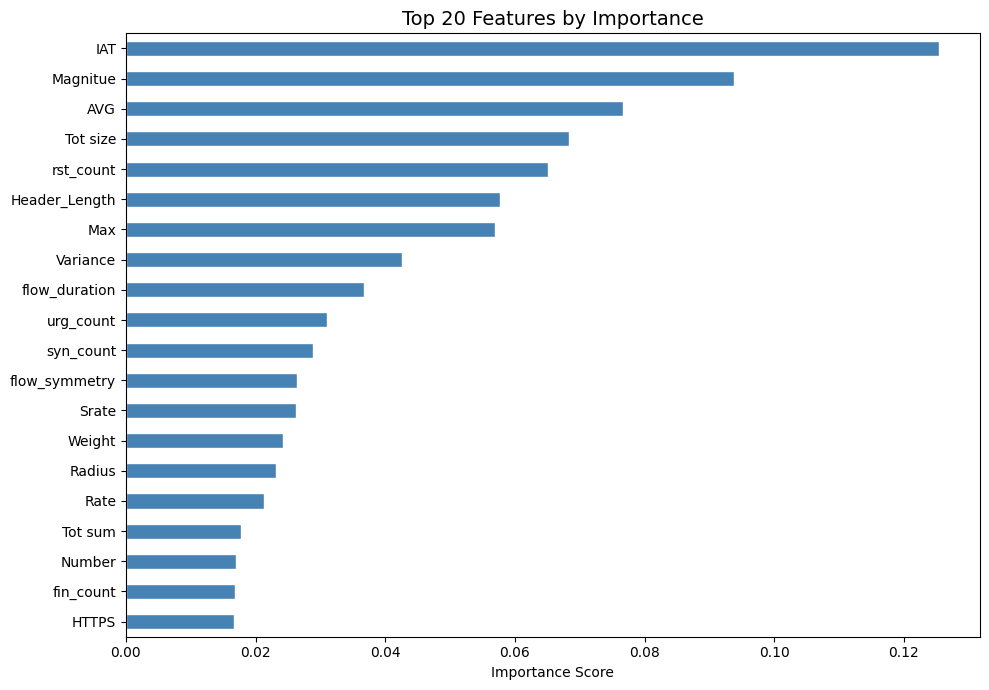

✔ Saved → results/feature_importance.png

Shape after feature selection : (74070, 20)
✔ Normalized  — mean ≈ 0.0000, std ≈ 1.0000

✔ Saved → models/scaler.pkl
✔ Saved → models/feature_cols.pkl
✔ Saved → data/X_scaled.npy
✔ Saved → data/y.npy


In [6]:
# Cell 5 — Feature Selection & Normalization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os
from sklearn.ensemble      import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

os.makedirs("models",  exist_ok=True)
os.makedirs("results", exist_ok=True)

df = pd.read_csv("data/cleaned_enhanced.csv")
X  = df.drop("label", axis=1)
y  = df["label"].astype(int)

print(f"Features before selection : {X.shape[1]}")
print(f"Training samples          : {len(X):,}")

# ── Train quick Random Forest to rank features ───────────────
print("\n⏳ Computing feature importance...")
rf_quick = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
rf_quick.fit(X, y)

# ── Rank features by importance score ────────────────────────
importance   = pd.Series(rf_quick.feature_importances_, index=X.columns)
importance   = importance.sort_values(ascending=False)

print("\nAll features ranked by importance:")
print("-" * 45)
for i, (feat, score) in enumerate(importance.items(), 1):
    bar = "█" * int(score * 200)
    print(f"  {i:2}. {feat:<25} {score:.4f}  {bar}")

# ── Select top 20 features ───────────────────────────────────
TOP_N        = 20
top_features = importance.head(TOP_N).index.tolist()

print(f"\n✔ Selected top {TOP_N} features:")
print(top_features)

# ── Plot feature importance ───────────────────────────────────
plt.figure(figsize=(10, 7))
importance.head(TOP_N).sort_values().plot(
    kind="barh", color="steelblue", edgecolor="white")
plt.title(f"Top {TOP_N} Features by Importance", fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("results/feature_importance.png", dpi=150)
plt.show()
print("✔ Saved → results/feature_importance.png")

# ── Keep only top features ────────────────────────────────────
X_selected = X[top_features]
print(f"\nShape after feature selection : {X_selected.shape}")

# ── Normalize with StandardScaler ────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

print(f"✔ Normalized  — mean ≈ {X_scaled.mean():.4f}, std ≈ {X_scaled.std():.4f}")

# ── Save everything ───────────────────────────────────────────
joblib.dump(scaler,       "models/scaler.pkl")
joblib.dump(top_features, "models/feature_cols.pkl")
np.save("data/X_scaled.npy", X_scaled)
np.save("data/y.npy",        y.values)

print("\n✔ Saved → models/scaler.pkl")
print("✔ Saved → models/feature_cols.pkl")
print("✔ Saved → data/X_scaled.npy")
print("✔ Saved → data/y.npy")


In [7]:
# Cell 6 — SMOTE Balancing
import numpy as np
import collections
from imblearn.over_sampling import SMOTE

X = np.load("data/X_scaled.npy")
y = np.load("data/y.npy")

class_names = {0:"BENIGN", 1:"DDoS", 2:"Recon", 3:"Spoofing", 4:"BruteForce"}

print("="*50)
print("BEFORE SMOTE")
print("="*50)
for cls, count in sorted(collections.Counter(y.astype(int)).items()):
    bar = "█" * (count // 500)
    print(f"  {class_names[cls]:<12} ({cls})  {count:>7,}  {bar}")

print("\n⏳ Applying SMOTE — takes 1-2 minutes...")
sm = SMOTE(random_state=42, k_neighbors=3)
X_balanced, y_balanced = sm.fit_resample(X, y)

print("\n"+"="*50)
print("AFTER SMOTE")
print("="*50)
for cls, count in sorted(collections.Counter(y_balanced.astype(int)).items()):
    bar = "█" * (count // 500)
    print(f"  {class_names[cls]:<12} ({cls})  {count:>7,}  {bar}")

print(f"\nDataset size : {len(X):,} → {len(X_balanced):,} samples")

np.save("data/X_final.npy", X_balanced)
np.save("data/y_final.npy", y_balanced)
print("✔ Saved → data/X_final.npy")
print("✔ Saved → data/y_final.npy")

BEFORE SMOTE
  BENIGN       (0)   19,878  ███████████████████████████████████████
  DDoS         (1)   19,995  ███████████████████████████████████████
  Recon        (2)   13,961  ███████████████████████████
  Spoofing     (3)   18,950  █████████████████████████████████████
  BruteForce   (4)    1,286  ██

⏳ Applying SMOTE — takes 1-2 minutes...

AFTER SMOTE
  BENIGN       (0)   19,995  ███████████████████████████████████████
  DDoS         (1)   19,995  ███████████████████████████████████████
  Recon        (2)   19,995  ███████████████████████████████████████
  Spoofing     (3)   19,995  ███████████████████████████████████████
  BruteForce   (4)   19,995  ███████████████████████████████████████

Dataset size : 74,070 → 99,975 samples
✔ Saved → data/X_final.npy
✔ Saved → data/y_final.npy


Class weights:
  BENIGN       → 1.0000
  DDoS         → 1.0000
  Recon        → 1.0000
  Spoofing     → 1.0000
  BruteForce   → 1.0000

⏳ Training improved Random Forest (300 trees)...

✔ Done in 25.4s
  Train : 99.65%
  Test  : 92.96%

              precision    recall  f1-score   support

      BENIGN       0.90      0.92      0.91      3999
        DDoS       1.00      1.00      1.00      3999
       Recon       0.91      0.87      0.89      3999
    Spoofing       0.91      0.87      0.89      3999
  BruteForce       0.93      0.99      0.96      3999

    accuracy                           0.93     19995
   macro avg       0.93      0.93      0.93     19995
weighted avg       0.93      0.93      0.93     19995



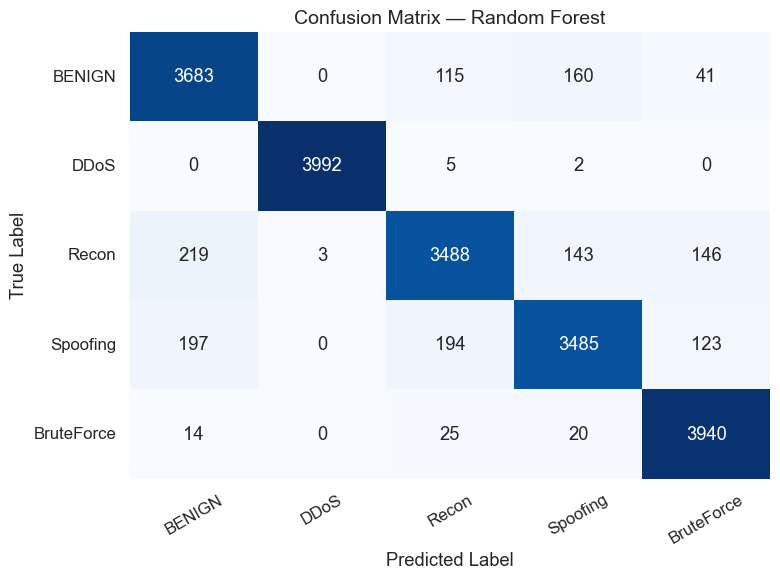


PER CLASS ACCURACY:
-------------------------------------------------------
  BENIGN      : 92.1%  ██████████████████  (was 91.6% → +0.5%)
  DDoS        : 99.8%  ███████████████████  (was 99.8% → +0.0%)
  Recon       : 87.2%  █████████████████  (was 83.3% → +3.9%)
  Spoofing    : 87.1%  █████████████████  (was 85.0% → +2.1%)
  BruteForce  : 98.5%  ███████████████████  (was 98.4% → +0.1%)

✔ Saved → models/Random_Forest.pkl
✔ Saved → models/ids_pipeline.pkl

🎯 New model ready — 92.96% overall accuracy
🔄 Restart app.py to load improved model into IDS engine


In [2]:
import numpy as np
import joblib, time, os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load Data ───────────────────────────────────────────────
X = np.load("data/X_final.npy")
y = np.load("data/y_final.npy")

class_names = ["BENIGN", "DDoS", "Recon", "Spoofing", "BruteForce"]

# ── Train-Test Split ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

np.save("data/X_test.npy", X_test)
np.save("data/y_test.npy", y_test)

# ── Compute Class Weights ───────────────────────────────────
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

cw = dict(zip(np.unique(y_train).astype(int), weights))

print("Class weights:")
for cls, w in cw.items():
    print(f"  {class_names[cls]:<12} → {w:.4f}")

# ── Train Model ─────────────────────────────────────────────
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight=cw,
    n_jobs=-1,
    random_state=42
)

print("\n⏳ Training improved Random Forest (300 trees)...")
start = time.time()
model.fit(X_train, y_train)
elapsed = time.time() - start

train_acc = model.score(X_train, y_train) * 100
test_acc  = model.score(X_test,  y_test)  * 100

print(f"\n✔ Done in {elapsed:.1f}s")
print(f"  Train : {train_acc:.2f}%")
print(f"  Test  : {test_acc:.2f}%")

# ── Predictions ─────────────────────────────────────────────
y_pred = model.predict(X_test)

# ── Classification Report ───────────────────────────────────
print("\n" + "="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

# ── Clean Confusion Matrix (No % and No Color Bar) ───────────
sns.set(font_scale=1.1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=False)   # ❌ removes side color bar

plt.title("Confusion Matrix — Random Forest", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()

# Save clean version
os.makedirs("results", exist_ok=True)
plt.savefig("results/confusion_matrix_clean.png", dpi=200)

plt.show()

# ── Per Class Accuracy ──────────────────────────────────────
print("\nPER CLASS ACCURACY:")
print("-" * 55)

for i, cls in enumerate(class_names):
    correct = cm[i][i]
    total   = cm[i].sum()
    pct     = correct / total * 100 if total > 0 else 0
    bar     = "█" * int(pct // 5)

    before  = [91.6, 99.8, 83.3, 85.0, 98.4]
    diff    = pct - before[i]

    print(f"  {cls:<12}: {pct:.1f}%  {bar}  (was {before[i]:.1f}% → {'+' if diff>=0 else ''}{diff:.1f}%)")

# ── Save Model & Pipeline ───────────────────────────────────
scaler       = joblib.load("models/scaler.pkl")
feature_cols = joblib.load("models/feature_cols.pkl")

pipeline = {
    "model": model,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "label_map": {
        0: "BENIGN",
        1: "DDoS",
        2: "Recon",
        3: "Spoofing",
        4: "BruteForce"
    },
    "accuracy": f"{test_acc:.2f}%"
}

os.makedirs("models", exist_ok=True)

joblib.dump(model,    "models/Random_Forest.pkl")
joblib.dump(pipeline, "models/ids_pipeline.pkl")

print("\n✔ Saved → models/Random_Forest.pkl")
print("✔ Saved → models/ids_pipeline.pkl")

print(f"\n🎯 New model ready — {test_acc:.2f}% overall accuracy")
print("🔄 Restart app.py to load improved model into IDS engine")

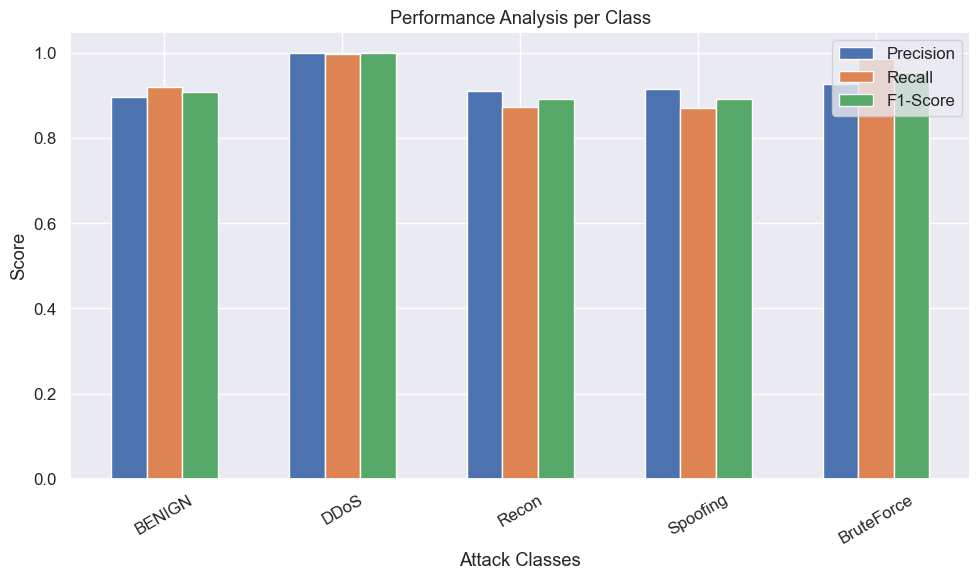

In [3]:
# ── Performance Analysis Diagram ────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Per-class metrics
precision = precision_score(y_test, y_pred, average=None)
recall    = recall_score(y_test, y_pred, average=None)
f1        = f1_score(y_test, y_pred, average=None)

x = np.arange(len(class_names))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x,         recall,    width, label='Recall')
plt.bar(x + width, f1,        width, label='F1-Score')

plt.xticks(x, class_names, rotation=30)
plt.xlabel("Attack Classes")
plt.ylabel("Score")
plt.title("Performance Analysis per Class")
plt.legend()

plt.tight_layout()

# Save figure
plt.savefig("results/performance_analysis.png", dpi=200)

plt.show()

RANDOM FOREST — EVALUATION RESULTS
  Accuracy  : 92.96%
  Precision : 92.96%
  Recall    : 92.96%
  F1-Score  : 92.92%

PER CLASS REPORT
              precision    recall  f1-score   support

      BENIGN       0.90      0.92      0.91      3999
        DDoS       1.00      1.00      1.00      3999
       Recon       0.91      0.87      0.89      3999
    Spoofing       0.91      0.87      0.89      3999
  BruteForce       0.93      0.99      0.96      3999

    accuracy                           0.93     19995
   macro avg       0.93      0.93      0.93     19995
weighted avg       0.93      0.93      0.93     19995



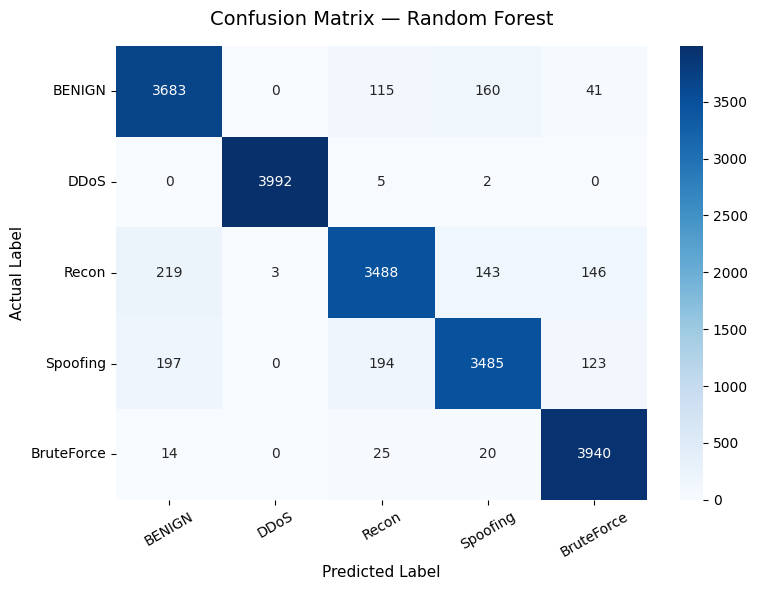

✔ Saved → results/confusion_matrix_RF.png

PER CLASS ACCURACY BREAKDOWN
  BENIGN       :  3683/3999  (92.1%)  ██████████████████
  DDoS         :  3992/3999  (99.8%)  ███████████████████
  Recon        :  3488/3999  (87.2%)  █████████████████
  Spoofing     :  3485/3999  (87.1%)  █████████████████
  BruteForce   :  3940/3999  (98.5%)  ███████████████████

✔ Saved → models/ids_pipeline.pkl
  Model accuracy : 92.96%
  Model F1-Score : 92.92%


In [9]:
# Cell 8 — Evaluate Random Forest
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)

os.makedirs("results", exist_ok=True)

# ── Load model and test data ─────────────────────────────────
model  = joblib.load("models/Random_Forest.pkl")
X_test = np.load("data/X_test.npy")
y_test = np.load("data/y_test.npy")

class_names = ["BENIGN", "DDoS", "Recon", "Spoofing", "BruteForce"]

# ── Predictions ──────────────────────────────────────────────
y_pred = model.predict(X_test)

# ── Metrics ──────────────────────────────────────────────────
acc  = accuracy_score (y_test, y_pred) * 100
prec = precision_score(y_test, y_pred, average="weighted") * 100
rec  = recall_score   (y_test, y_pred, average="weighted") * 100
f1   = f1_score       (y_test, y_pred, average="weighted") * 100

print("="*55)
print("RANDOM FOREST — EVALUATION RESULTS")
print("="*55)
print(f"  Accuracy  : {acc:.2f}%")
print(f"  Precision : {prec:.2f}%")
print(f"  Recall    : {rec:.2f}%")
print(f"  F1-Score  : {f1:.2f}%")

print("\n"+"="*55)
print("PER CLASS REPORT")
print("="*55)
print(classification_report(y_test, y_pred,
                             target_names=class_names))

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix — Random Forest", fontsize=14, pad=15)
plt.ylabel("Actual Label",    fontsize=11)
plt.xlabel("Predicted Label", fontsize=11)
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("results/confusion_matrix_RF.png", dpi=150)
plt.show()
print("✔ Saved → results/confusion_matrix_RF.png")

# ── Per class accuracy breakdown ─────────────────────────────
print("\n"+"="*55)
print("PER CLASS ACCURACY BREAKDOWN")
print("="*55)
for i, cls in enumerate(class_names):
    correct = cm[i][i]
    total   = cm[i].sum()
    pct     = correct / total * 100
    bar     = "█" * int(pct // 5)
    print(f"  {cls:<12} : {correct:>5}/{total}  ({pct:.1f}%)  {bar}")

# ── Save pipeline ────────────────────────────────────────────
scaler       = joblib.load("models/scaler.pkl")
feature_cols = joblib.load("models/feature_cols.pkl")

pipeline = {
    "model":        model,
    "scaler":       scaler,
    "feature_cols": feature_cols,
    "label_map":    {0:"BENIGN", 1:"DDoS", 2:"Recon",
                     3:"Spoofing", 4:"BruteForce"},
    "accuracy":     f"{acc:.2f}%",
    "f1_score":     f"{f1:.2f}%"
}

joblib.dump(pipeline, "models/ids_pipeline.pkl")
print("\n✔ Saved → models/ids_pipeline.pkl")
print(f"  Model accuracy : {acc:.2f}%")
print(f"  Model F1-Score : {f1:.2f}%")
